In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import linregress


# Define file paths: 
> **data_filelaCO** = data from plate reader: Copy and paste into an excel file the raw table of absorbance reads given by plate reader. Note the rows where the table starts. Ideally start at A1.

> **layout_file**  = is a csv file that contains the well:sample definition. This can be very different to the SEC plate due to standards and can be exported directly from Benchling if using the protocol. 
  Otherwise, produce a table with paired well name and sample name and comment the well_to_sample_map.
  
> **Concentration_data** - Concentration of each standard loaded onto the plate. Use same label as plate layout - more specification and an example is given on the benchling protocol  https://benchling.com/s/prt-Ia4VDTY8MrHeVpU7a8xT?m=slm-VZTe4mU62ZmlRfQ68yIk

In [3]:
os.chdir("/mnt/home/yensifb/software/ds_expression/Ellman/")
print(os.getcwd())

/mnt/home/yensifb/software/ds_expression/Ellman


In [4]:
# File paths
data_path = '20240607_ellmans_secpep_gg.xlsx' 
layout_file = '20240610_layout.csv'
concentration_data = pd.read_csv('standards.csv')


# Load the data
data = pd.read_excel(data_path, usecols="A:CS", skiprows=2, nrows=302, header=0) #Check the table distribution 
data.set_index('Wavelength', inplace=True)

# Now 'data' DataFrame has Wavelength as the index and row 24 from the Excel file as headers
print("Data loaded with Wavelength as index and proper headers:")
print(data.head())

Data loaded with Wavelength as index and proper headers:
               A1     A2     A3     A4     A5     A6     A7     A8     A9  \
Wavelength                                                                  
325         0.183  0.197  0.185  1.006  0.309  0.311  0.302  0.319  0.319   
326         0.183  0.199  0.183  0.992  0.307  0.311  0.302  0.318  0.318   
327         0.185  0.199  0.184  0.998  0.307  0.310  0.300  0.317  0.317   
328         0.186  0.199  0.187  1.010  0.306  0.309  0.300  0.316  0.317   
329         0.186  0.202  0.188  1.021  0.305  0.308  0.299  0.315  0.316   

              A10  ...     H3     H4     H5     H6     H7     H8     H9  \
Wavelength         ...                                                    
325         0.306  ...  0.333  0.408  0.400  0.396  0.398  0.412  0.403   
326         0.305  ...  0.332  0.407  0.399  0.395  0.397  0.411  0.402   
327         0.304  ...  0.331  0.405  0.398  0.394  0.396  0.409  0.400   
328         0.303  ...  0.32

### Define well distribution and average data from replicates
    *(if not in a 1:1 column format)*

In [5]:
# Process sample layout from CSV to create well_to_sample_map
def process_sample_layout(layout_file):
    sample_layout = pd.read_csv(layout_file, header=0, index_col=0)
    rows = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
    cols = [str(i) for i in range(1, 13)]
    well_data = []
    for row in rows:
        for col in cols:
            sample = sample_layout.at[row, col] if col in sample_layout.columns and row in sample_layout.index else 'NaN'
            well_data.append({'Well': f'{row}{col}', 'Sample': sample})
    return pd.DataFrame(well_data)

# Process the layout file to create well_to_sample_map if needed (assuming this part is clear)
well_df = process_sample_layout(layout_file)
well_to_sample_map = dict(zip(well_df['Well'], well_df['Sample']))

# Relabel the columns based on the well_to_sample_map
data.columns = [well_to_sample_map.get(col, col) for col in data.columns]

# Remove columns where the sample name is NaN
data = data.loc[:, ~data.columns.isna()]  # This ensures only non-NaN columns are retained

# Additionally, you might have string 'NaN' which should be handled
data = data.loc[:, data.columns != 'NaN']

# Transpose data for easier manipulation
data = data.T

# Group by sample names (which are now the index after transpose) and calculate the mean
# This effectively averages the absorbance readings for each sample across its replicates
averaged_data = data.groupby(data.index).mean()

# Transpose back if needed for easier plotting or analysis
averaged_data = averaged_data.T

# Print to check the processed data
print("Processed Averaged Data:")
print(averaged_data.head())

Processed Averaged Data:
               A1    A10    A11    A12     A2     A3     A4     A5     A6  \
Wavelength                                                                  
325         1.006  0.359  0.295  0.314  0.309  0.311  0.302  0.319  0.319   
326         0.992  0.357  0.294  0.313  0.307  0.311  0.302  0.318  0.318   
327         0.998  0.356  0.293  0.312  0.307  0.310  0.300  0.317  0.317   
328         1.010  0.355  0.292  0.312  0.306  0.309  0.300  0.316  0.317   
329         1.021  0.354  0.291  0.310  0.305  0.308  0.299  0.315  0.316   

               A7  ...     F1        NC       S01       S02       S03  \
Wavelength         ...                                                  
325         0.306  ...  0.300  0.401333  0.188333  0.152000  0.206000   
326         0.305  ...  0.299  0.400333  0.188333  0.152333  0.206333   
327         0.304  ...  0.298  0.399000  0.189333  0.153667  0.207333   
328         0.303  ...  0.297  0.397667  0.190667  0.155333  0.208333 

### Visualise the absorbance scpectra of the sample

/scratch/yensifb/6708687/ipykernel_2846905/2588136962.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # Adjust layout to not overlap elements


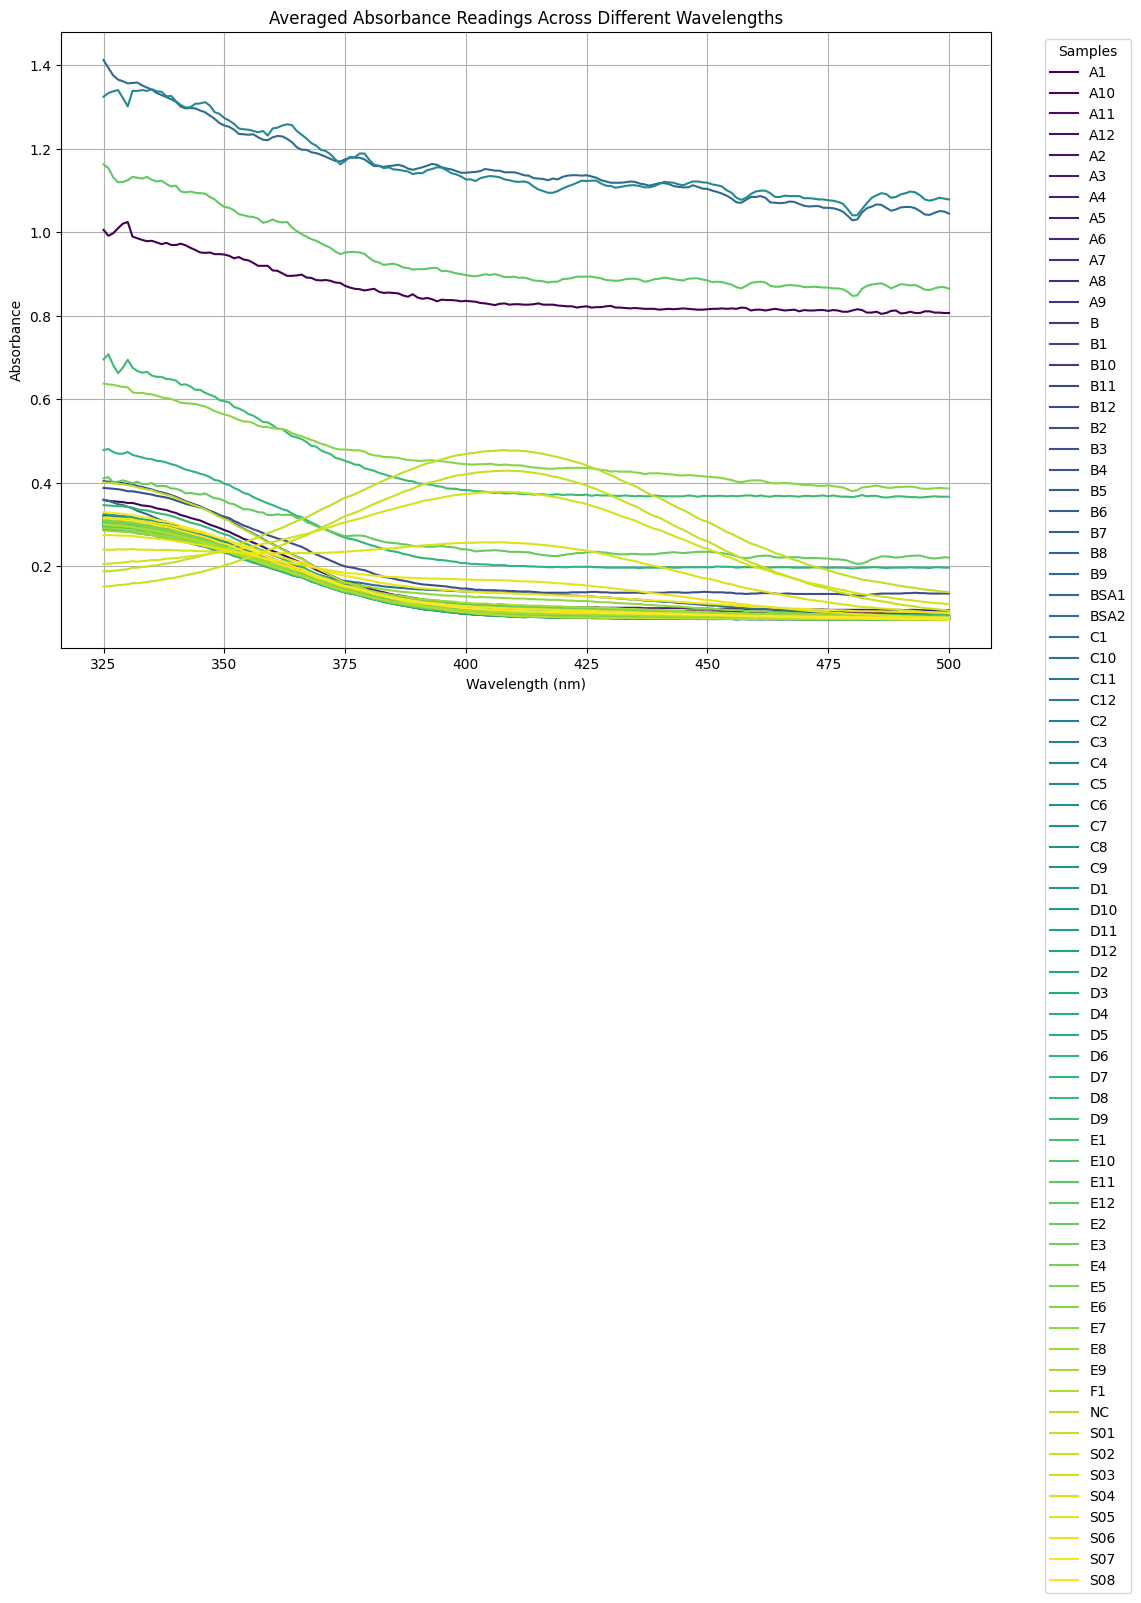

In [6]:
def plot_absorbance(averaged_data):
    # Create the figure and axis for plotting
    plt.figure(figsize=(12, 8))
    
    # Generate a color map to give each sample a unique color
    cmap = plt.get_cmap('viridis')  # You can choose any colormap you like
    colors = cmap(np.linspace(0, 1, len(averaged_data.columns)))

    # Plot each sample's averaged absorbance across the wavelengths
    for i, column in enumerate(averaged_data.columns):
        plt.plot(averaged_data.index, averaged_data[column], label=column, color=colors[i])
    
    # Add legend, labels, and title to the plot
    plt.legend(title='Samples', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Absorbance')
    plt.title('Averaged Absorbance Readings Across Different Wavelengths')
    plt.grid(True)
    plt.tight_layout()  # Adjust layout to not overlap elements
    plt.show()

# Assuming 'averaged_data' is your DataFrame after averaging across replicates
plot_absorbance(averaged_data)

### Filter data from the wavelenghts needed (408 nm)

/scratch/yensifb/6708687/ipykernel_2846905/3714916402.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # Adjust layout to not overlap elements


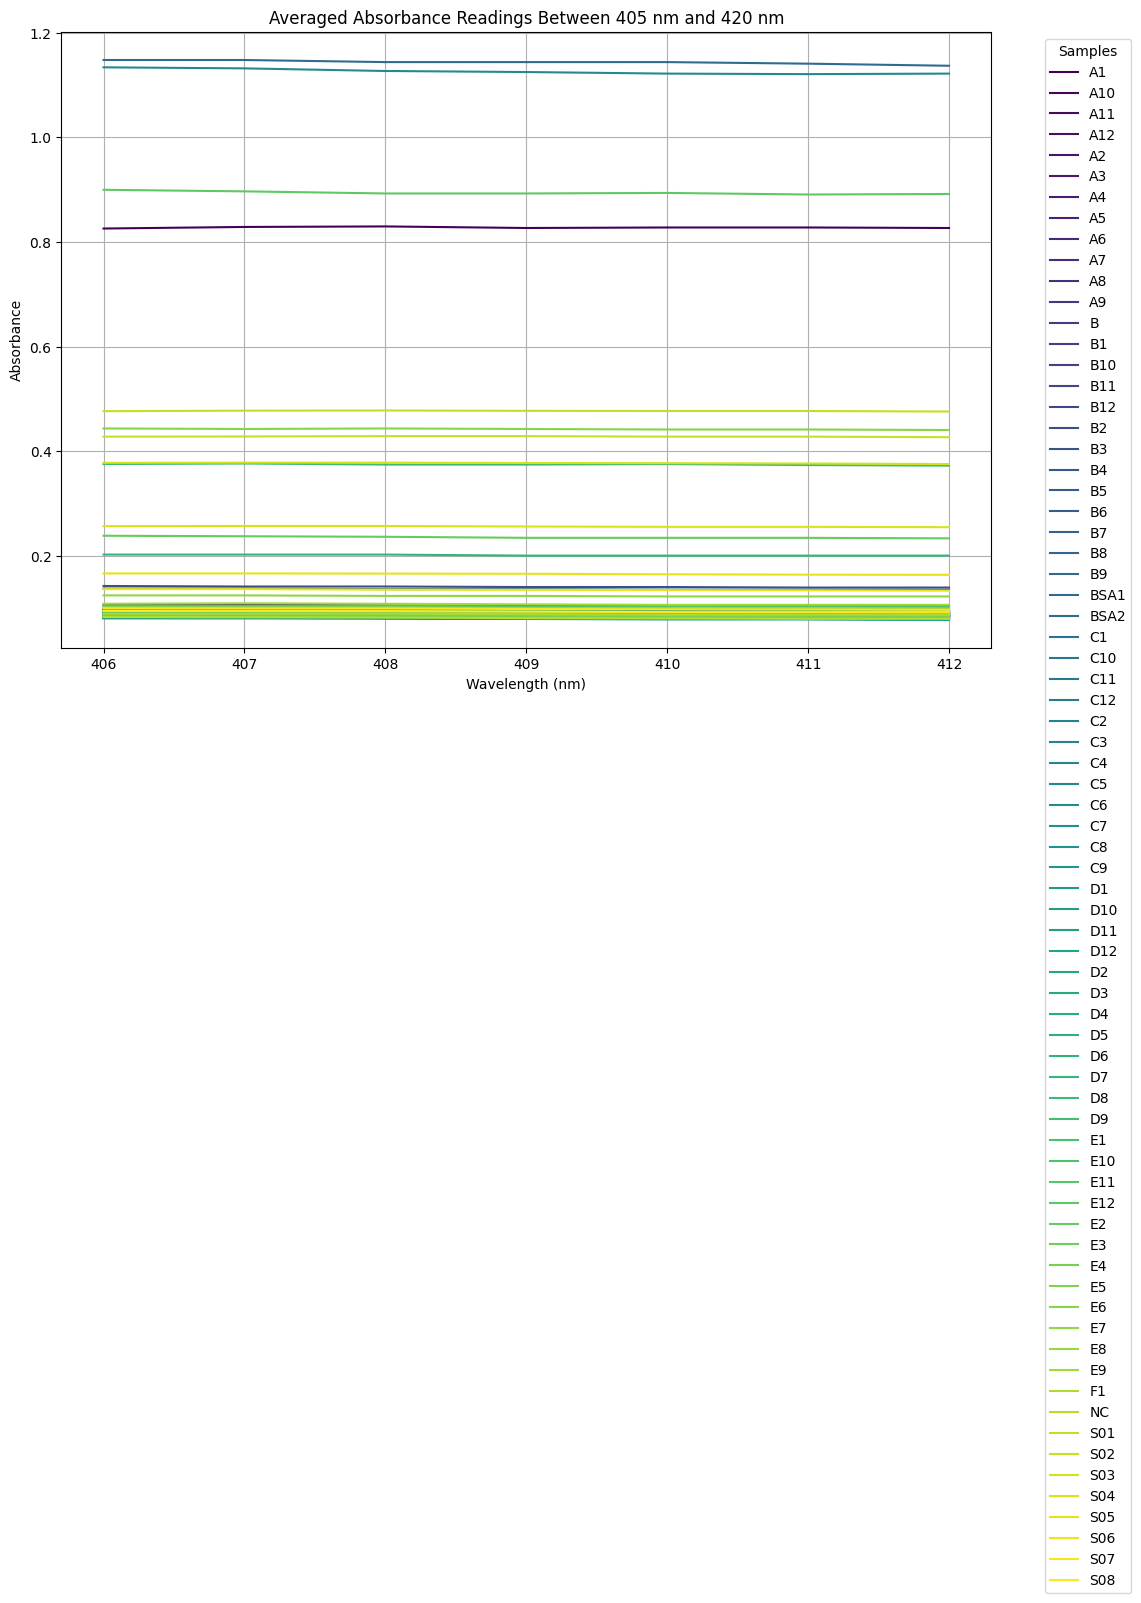

In [7]:
# Filter the data to include only wavelengths between 405 nm and 420 nm
filtered_data = averaged_data.loc[(averaged_data.index >= 406) & (averaged_data.index <= 412)]

def plot_filtered_absorbance(filtered_data):
    # Create the figure and axis for plotting
    plt.figure(figsize=(12, 8))
    
    # Generate a color map to give each sample a unique color
    cmap = plt.get_cmap('viridis')  # You can choose any colormap you like
    colors = cmap(np.linspace(0, 1, len(filtered_data.columns)))

    # Plot each sample's averaged absorbance across the wavelengths
    for i, column in enumerate(filtered_data.columns):
        plt.plot(filtered_data.index, filtered_data[column], label=column, color=colors[i])
    
    # Add legend, labels, and title to the plot
    plt.legend(title='Samples', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Absorbance')
    plt.title('Averaged Absorbance Readings Between 405 nm and 420 nm')
    plt.grid(True)
    plt.tight_layout()  # Adjust layout to not overlap elements
    plt.show()

# Call the function to plot the filtered data
plot_filtered_absorbance(filtered_data)


### Find the maximum absorbance reads per sample

In [8]:
def find_max_absorbance(filtered_data):
    # Find the maximum absorbance value in each column and the corresponding wavelength
    max_values = {}
    for column in filtered_data.columns:
        max_index = filtered_data[column].idxmax()  # Get the index (wavelength) of the max absorbance
        max_absorbance = filtered_data[column].max()  # Get the max absorbance value
        max_values[column] = (max_index, max_absorbance)  # Store in a dictionary

    return max_values

# Calculate max absorbance values for the filtered data
max_absorbance_values = find_max_absorbance(filtered_data)

# Print the results
print("Maximum Absorbance Values and Their Wavelengths:")
for sample, values in max_absorbance_values.items():
    print(f"{sample}: Maximum absorbance of {values[1]:.3f} at {values[0]} nm")


Maximum Absorbance Values and Their Wavelengths:
A1: Maximum absorbance of 0.830 at 408 nm
A10: Maximum absorbance of 0.100 at 406 nm
A11: Maximum absorbance of 0.087 at 406 nm
A12: Maximum absorbance of 0.082 at 406 nm
A2: Maximum absorbance of 0.095 at 406 nm
A3: Maximum absorbance of 0.099 at 406 nm
A4: Maximum absorbance of 0.085 at 406 nm
A5: Maximum absorbance of 0.107 at 406 nm
A6: Maximum absorbance of 0.095 at 406 nm
A7: Maximum absorbance of 0.090 at 406 nm
A8: Maximum absorbance of 0.082 at 406 nm
A9: Maximum absorbance of 0.088 at 406 nm
B: Maximum absorbance of 0.083 at 406 nm
B1: Maximum absorbance of 0.096 at 406 nm
B10: Maximum absorbance of 0.089 at 407 nm
B11: Maximum absorbance of 0.088 at 406 nm
B12: Maximum absorbance of 0.089 at 406 nm
B2: Maximum absorbance of 0.143 at 406 nm
B3: Maximum absorbance of 0.089 at 406 nm
B4: Maximum absorbance of 0.088 at 406 nm
B5: Maximum absorbance of 0.093 at 406 nm
B6: Maximum absorbance of 0.087 at 406 nm
B7: Maximum absorbance

### Calculate the standard curve
> **concentration_data** = a csv file with a table defining name and standard concentrations

> This cell plots all concentration to visualise the curve behaivor

Slope: 0.008363162802010701
Intercept: 0.08738207732014483
R-squared: 0.9866005521364185


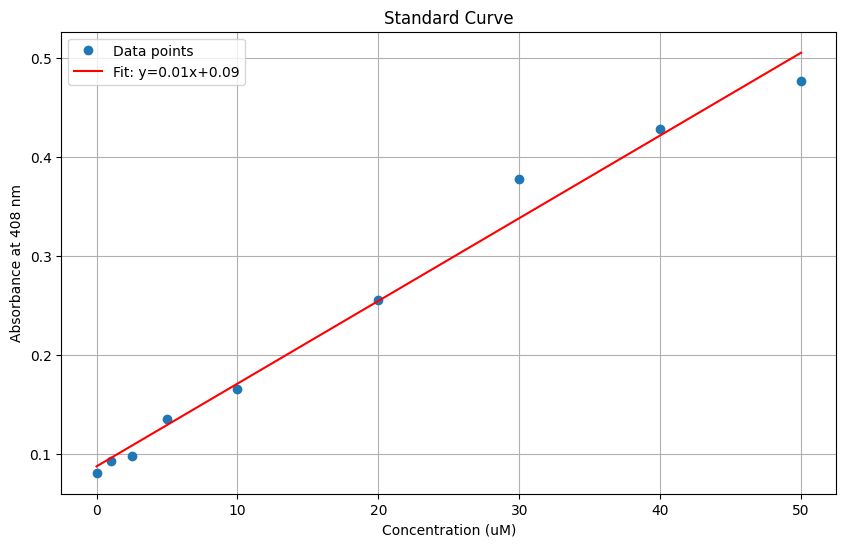

In [9]:
# Assuming 'averaged_data' is your DataFrame and you have wavelengths as the index
absorbance_at_410 = averaged_data.loc[410]

# Map the absorbance to the corresponding concentrations
# 'Standard' in concentration_data matches columns in absorbance_at_410
concentration_data['Absorbance'] = concentration_data['Standard'].map(absorbance_at_410)

# Drop any rows where Absorbance is NaN (this might happen if some standards are not in your absorbance data)
concentration_data.dropna(subset=['Absorbance'], inplace=True)

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(concentration_data['uM_Concentration'], concentration_data['Absorbance'])

# Print the regression results
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

# Plot the standard curve
plt.figure(figsize=(10, 6))
plt.plot(concentration_data['uM_Concentration'], concentration_data['Absorbance'], 'o', label='Data points')
plt.plot(concentration_data['uM_Concentration'], intercept + slope * concentration_data['uM_Concentration'], 'r', label='Fit: y={:.2f}x+{:.2f}'.format(slope, intercept))
plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance at 408 nm')
plt.title('Standard Curve')
plt.legend()
plt.grid(True)
plt.show()


### Filter standards used (Useful for unknonw concentrations and wide standard curves)

Slope: 0.008310300528243383
Intercept: 0.08922717078417794
R-squared: 0.9847915264752646


/scratch/yensifb/6708687/ipykernel_2846905/349215048.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  concentration_data_filtered.dropna(subset=['Absorbance'], inplace=True)


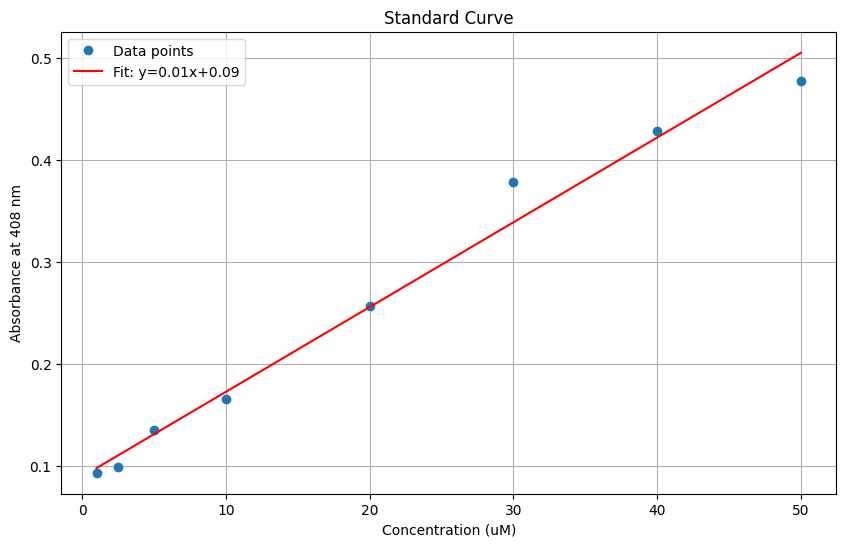

In [10]:

#DEFINING STANDARDS TO USE TO GET CONCENTRATION: 

# Filter out higher concentration standards (e.g., greater than S04)
concentration_data_filtered = concentration_data[concentration_data['Standard'].isin(['S01','S02','S03','S04','S05', 'S06', 'S07', 'S08','NC1'])]

# Drop any rows where Absorbance is NaN (this might happen if some standards are not in your absorbance data)
concentration_data_filtered.dropna(subset=['Absorbance'], inplace=True)

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(concentration_data_filtered['uM_Concentration'], concentration_data_filtered['Absorbance'])

# Print the regression results
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

# Plot the standard curve
plt.figure(figsize=(10, 6))
plt.plot(concentration_data_filtered['uM_Concentration'], concentration_data_filtered['Absorbance'], 'o', label='Data points')
plt.plot(concentration_data_filtered['uM_Concentration'], intercept + slope * concentration_data_filtered['uM_Concentration'], 'r', label='Fit: y={:.2f}x+{:.2f}'.format(slope, intercept))
plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance at 408 nm')
plt.title('Standard Curve')
plt.legend()
plt.grid(True)
plt.show()


## DETERMINING THE UNKNOWN CONCENTRATION (with defined standards)

Unknowns with Calculated Concentrations:
A1     88.557157
A10     1.269606
A11    -0.284830
A12    -0.882690
A2      0.671746
         ...    
E6     42.402370
E7      4.258906
E8      1.628322
E9      2.345754
F1      0.073886
Name: 410, Length: 64, dtype: float64
Slope: 0.008363162802010701
Intercept: 0.08738207732014483
R-squared: 0.9866005521364185


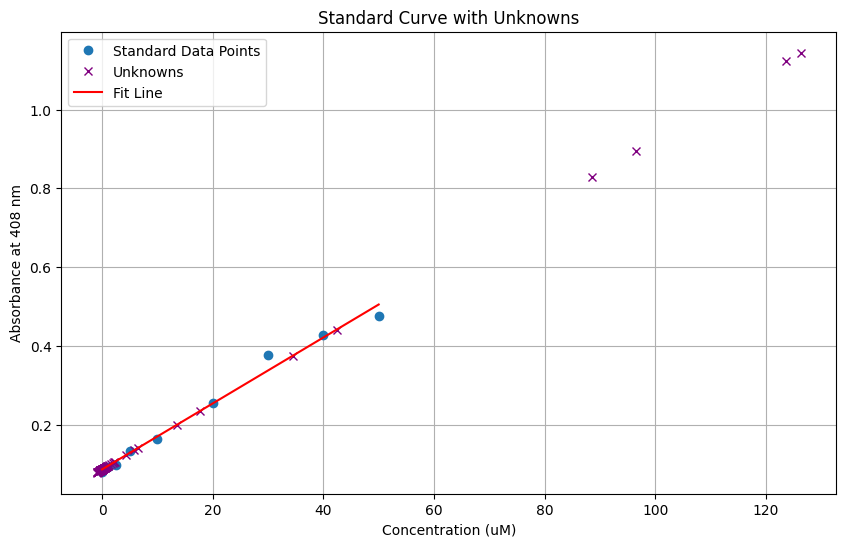

In [14]:
concentration_data['Absorbance'] = concentration_data['Standard'].map(absorbance_at_410)

### *Define the subset of standards you are interested in* #####
subset_standards = ['S01','S02','S03','S04','S05', 'S06', 'S07', 'S08','NC']
standard_data = concentration_data[concentration_data['Standard'].isin(subset_standards)]

# Drop any rows where Absorbance is NaN
standard_data.dropna(subset=['Absorbance'], inplace=True)

# Perform linear regression on the standard data
slope, intercept, r_value, p_value, std_err = linregress(standard_data['uM_Concentration'], standard_data['Absorbance'])

# Identify all absorbance data entries that are not in the known standard list
unknowns_absorbance = absorbance_at_410[~absorbance_at_410.index.isin(concentration_data['Standard'])]

# Calculate concentrations for the unknowns with the regression model
unknowns_concentration = (unknowns_absorbance - intercept) / slope

# Display unknowns and their calculated concentrations
print("Unknowns with Calculated Concentrations:")
print(unknowns_concentration)


# Print the regression results
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

# Save the data to a CSV file
standard_data.to_csv('standard_output.csv', index=False)
unknowns_concentration.to_csv('unknowns_output.csv')



# Plotting linear regression
plt.figure(figsize=(10, 6))
plt.plot(standard_data['uM_Concentration'], standard_data['Absorbance'], 'o', label='Standard Data Points')
plt.plot(unknowns_concentration, unknowns_absorbance, 'x', label='Unknowns', color='purple')
plt.plot([0, max(standard_data['uM_Concentration'])], [intercept + slope * 0, intercept + slope * max(standard_data['uM_Concentration'])], 'r-', label='Fit Line')
plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance at 408 nm')
plt.title('Standard Curve with Unknowns')
plt.legend()
plt.grid(True)
plt.savefig('standard_curve_with_unknowns.png')
plt.show()



In [ ]:
# Function to subtract background signal

def subtract_background(absorbance_data, blank_label='BLANK'):
    # Identify and calculate the mean background signal
    background_signal = absorbance_data[absorbance_data.index.str.contains(blank_label)].mean()
    # Subtract the background signal from all absorbance values
    corrected_absorbance = absorbance_data - background_signal
    return corrected_absorbance, background_signal

# Map absorbance to known standards in concentration_data
concentration_data['Absorbance'] = concentration_data['Standard'].map(absorbance_at_408)

# Use only the subset of standards you are interested in
subset_standards = ['S01', 'S02', 'S04', 'S05', 'S06', 'S07', 'S08', 'NC1']
standard_data = concentration_data[concentration_data['Standard'].isin(subset_standards)]

# Drop any rows where Absorbance is NaN
standard_data.dropna(subset=['Absorbance'], inplace=True)

# Subtract background signal from standard_data
corrected_absorbance, background_signal = subtract_background(absorbance_at_408)
standard_data['Absorbance'] = standard_data['Standard'].map(corrected_absorbance)

# Perform linear regression on the standard data
slope, intercept, r_value, p_value, std_err = linregress(standard_data['uM_Concentration'], standard_data['Absorbance'])

# Identify all absorbance data entries that are not in the known standard list
unknowns_absorbance = corrected_absorbance[~corrected_absorbance.index.isin(concentration_data['Standard'])]

# Calculate concentrations for the unknowns using the regression model
unknowns_concentration = (unknowns_absorbance - intercept) / slope

# Display unknowns and their calculated concentrations
print("Unknowns with Calculated Concentrations:")
print(unknowns_concentration)

# Print the regression results
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

# Plotting linear regression
plt.figure(figsize=(10, 6))
plt.plot(standard_data['uM_Concentration'], standard_data['Absorbance'], 'o', label='Standard Data Points')
plt.plot(unknowns_concentration, unknowns_absorbance, 'x', label='Unknowns', color='purple')
plt.plot([0, max(standard_data['uM_Concentration'])], [intercept + slope * 0, intercept + slope * max(standard_data['uM_Concentration'])], 'r-', label='Fit Line')
plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance at 408 nm')
plt.title('Standard Curve with Unknowns')
plt.legend()
plt.grid(True)
plt.show()

# Print the background signal for reference
print(f"Background Signal (BLANK wells): {background_signal}")


In [ ]:
#Save the concentrations of unknowns into a csv table 
unknowns_concentration.to_csv('unknowns_concentration_20240610.csv', index=True)

# Code for plotting the samples with different regression models - found not to fit well the standard curve of this essay in particular. 

[[Model]]
    Model(four_param_logistic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 94
    # data points      = 8
    # variables        = 4
    chi-square         = 0.00233904
    reduced chi-square = 5.8476e-04
    Akaike info crit   = -57.0996454
    Bayesian info crit = -56.7818792
    R-squared          = 0.98621429
[[Variables]]
    A:  0.03226444 +/- 0.01453371 (45.05%) (init = 0.3963333)
    B:  3.19561218 +/- 1.13223176 (35.43%) (init = 1)
    C:  21.6555476 +/- 2.49813384 (11.54%) (init = 15)
    D:  0.39633333 +/- 1.09700947 (276.79%) (init = 0.013)
[[Correlations]] (unreported correlations are < 0.100)
    C(B, D) = +0.8315
    C(C, D) = -0.7688
    C(B, C) = -0.4798
    C(A, B) = +0.4519
    C(A, D) = +0.3012


/scratch/yensifb/53150832/ipykernel_3800312/4222537759.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  standard_data.dropna(subset=['uM_Concentration', 'Absorbance'], inplace=True)


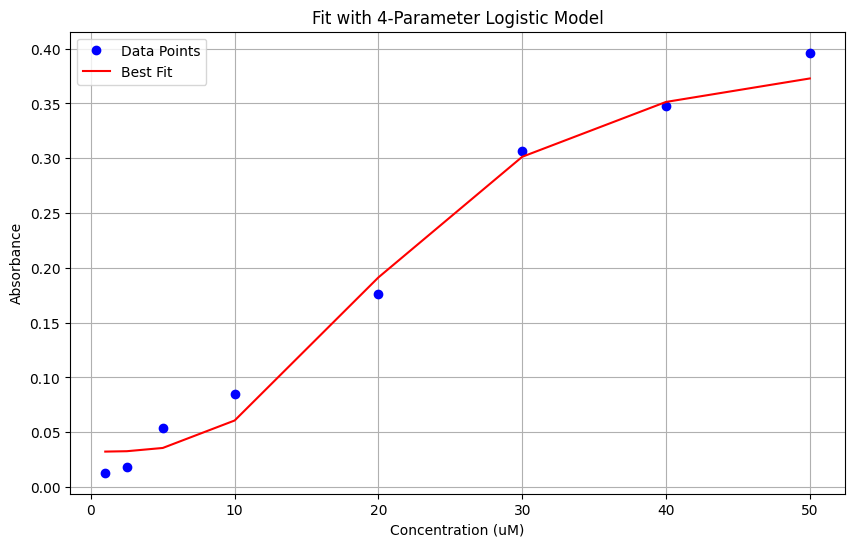

In [34]:
from lmfit import Model

# Check for NaN values and drop them
standard_data.dropna(subset=['uM_Concentration', 'Absorbance'], inplace=True)

# Ensure x and y are correctly aligned and have the same length
x = standard_data['uM_Concentration']
y = standard_data['Absorbance']
assert len(x) == len(y), "The lengths of x and y must be the same."

def four_param_logistic(x, A, B, C, D):
    return D + (A - D) / (1.0 + (x / C)**B)

model = Model(four_param_logistic)

# Using more realistic boundaries based on your data range
params = model.make_params(A=max(y), B=1, C=np.median(x), D=min(y))
params['A'].set(min=min(y), max=max(y)*1.2)
params['D'].set(min=min(y)*0.8, max=max(y))
params['B'].set(min=0.1, max=10)
params['C'].set(min=0, max=max(x)*2)

# Fit the model
result = model.fit(y, params, x=x, nan_policy='omit')

print(result.fit_report())

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'bo', label='Data Points')
plt.plot(x, result.best_fit, 'r-', label='Best Fit')
plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance')
plt.title('Fit with 4-Parameter Logistic Model')
plt.legend()
plt.grid(True)
plt.show()




In [62]:
from lmfit import Model
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Define the 4PL logistic model function
def four_param_logistic(x, A, B, C, D):
    return D + (A - D) / (1.0 + (x / C)**B)

# Create the model
model = Model(four_param_logistic)

# Assume concentration_data is your DataFrame that includes concentrations and you've mapped absorbance at 408 nm to it
# concentration_data['Absorbance'] = map from absorbance_at_408

# Filter to include only the subset of standards for fitting, explicitly removing 'S08'
subset_standards = ['S03','S04', 'S05', 'S06', 'S07', 'NC1']  # Exclude 'S08' and other unwanted standards
standard_data = concentration_data[concentration_data['Standard'].isin(subset_standards)]
standard_data.dropna(subset=['Absorbance'], inplace=True)

# Ensure 'S08' is not in the dataset
print("Standard data used for fitting:")
print(standard_data)

# Fit the 4PL model to the standard data
params = model.make_params(A=max(standard_data['Absorbance']), B=1, C=np.median(standard_data['uM_Concentration']), D=min(standard_data['Absorbance']))
result = model.fit(standard_data['Absorbance'], params, x=standard_data['uM_Concentration'])

# Print the fit report
print(result.fit_report())

# Use the fitted model to calculate concentrations for unknowns
def find_concentration(absorbance, A, B, C, D):
    func_to_solve = lambda x: four_param_logistic(x, A, B, C, D) - absorbance
    return fsolve(func_to_solve, C)[0]

# Assuming unknown_absorbances is a Series with unknown absorbances
unknown_concentrations = unknown_absorbances.apply(find_concentration, args=(result.params['A'].value, result.params['B'].value, result.params['C'].value, result.params['D'].value))

print("Unknowns with Calculated Concentrations:")
print(unknown_concentrations)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(standard_data['uM_Concentration'], standard_data['Absorbance'], 'bo', label='Standard Data Points')
plt.plot(x, result.best_fit, 'r-', label='Best Fit')
plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance')
plt.title('4-Parameter Logistic Model Fit')
plt.legend()
plt.grid(True)
plt.show()


Standard data used for fitting:
   Standard  uM_Concentration  Absorbance
2       S03               500     1.71525
3       S04               250     1.69100
4       S05               100     0.87475
5       S06                75     0.70975
6       S07                50     0.47325
11      NC1                 0     0.07300
[[Model]]
    Model(four_param_logistic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 131
    # data points      = 6
    # variables        = 4
    chi-square         = 0.02043976
    reduced chi-square = 0.01021988
    Akaike info crit   = -26.0921969
    Bayesian info crit = -26.9251590
    R-squared          = 0.99066704
[[Variables]]
    A:  0.09533158 +/- 0.09932781 (104.19%) (init = 1.71525)
    B:  2.08402025 +/- 0.59639446 (28.62%) (init = 1)
    C:  101.393614 +/- 15.2320749 (15.02%) (init = 87.5)
    D:  1.83130186 +/- 0.14734626 (8.05%) (init = 0.073)
[[Correlations]] (unreported correlations are < 0.100)
    C(B, D) = -0.7

/scratch/yensifb/42635118/ipykernel_1152646/1509731950.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  standard_data.dropna(subset=['Absorbance'], inplace=True)


NameError: name 'unknown_absorbances' is not defined

In [63]:
from lmfit import Model
import numpy as np
from scipy.optimize import fsolve

# Define the 4PL logistic model function
def four_param_logistic(x, A, B, C, D):
    return D + (A - D) / (1.0 + (x / C)**B)

# Create the model
model = Model(four_param_logistic)

# Assuming you have fitted the model and have the parameters result
# Let's assume 'result' is already available from your successful model fit

# Function to calculate concentration from absorbance using the 4PL model
def find_concentration(absorbance, A, B, C, D):
    # Define the function to find the root for
    func_to_solve = lambda x: four_param_logistic(x, A, B, C, D) - absorbance
    # Start the estimation around the middle of your concentration range
    estimated_concentration = fsolve(func_to_solve, C)
    return estimated_concentration[0]

# Extract the fitted parameters
A = result.params['A'].value
B = result.params['B'].value
C = result.params['C'].value
D = result.params['D'].value

# Now apply the concentration finding function to your unknowns
# Assume unknown_absorbances is a Pandas Series with index as labels and values as absorbances
unknown_concentrations = unknown_absorbances.apply(find_concentration, args=(A, B, C, D))

# Display calculated concentrations for unknowns
print("Unknowns with Calculated Concentrations:")
print(unknown_concentrations)

# For plotting, assuming you have x (concentration) and y (absorbance) from your data:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'bo', label='Standard Data Points')
plt.plot(x, result.eval(x=x), 'r-', label='Best Fit')
# Plotting unknowns if you wish to visualize them
for label, absorbance in unknown_absorbances.items():
    plt.plot(unknown_concentrations[label], absorbance, 'gx', label=f'Unknown - {label}')
plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance')
plt.title('4-Parameter Logistic Model Fit with Unknowns')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'unknown_absorbances' is not defined

NameError: name 'unknown_absorbances' is not defined

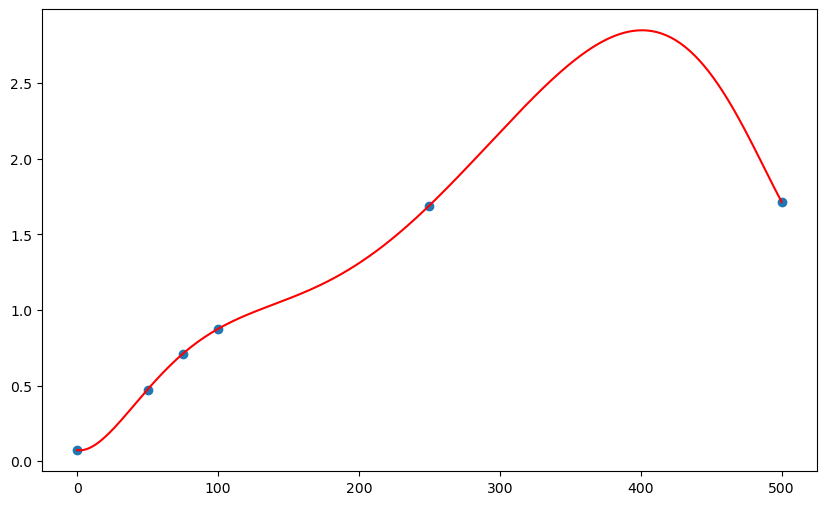

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial

# Sample data setup
x = np.array(standard_data['uM_Concentration'])
y = np.array(standard_data['Absorbance'])

# Fit a polynomial regression model
degree = 8  # Try adjusting this based on your visual inspection
coefs = Polynomial.fit(x, y, deg=degree)

# Function to calculate concentration from a given absorbance
def concentration_from_absorbance(absorbance, coefs):
    roots = np.roots(coefs.convert().coef - absorbance)
    real_roots = roots[np.isreal(roots)].real
    valid_roots = [root for root in real_roots if 0 <= root <= max(x)]
    return min(valid_roots, default=np.nan)

# Generate x values for plotting the polynomial curve
x_line = np.linspace(min(x), max(x), num=300)
y_line = coefs(x_line)

# Plotting the fit curve and data points
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o', label='Standard Data Points')
plt.plot(x_line, y_line, label=f'Polynomial Degree {degree}', linestyle='-', color='red')

# Assuming unknown_absorbances is defined and contains your unknown sample data
unknown_concentrations = unknown_absorbances.apply(concentration_from_absorbance, args=(coefs,))

# Plotting unknown concentrations if they're valid
for label, absorbance in unknown_absorbances.items():
    conc = concentration_from_absorbance(absorbance, coefs)
    if not np.isnan(conc):
        plt.plot(conc, absorbance, 'gx', label=f'Unknown - {label}')

plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance at 408 nm')
plt.title('Polynomial Regression Curve with Unknowns')
plt.legend()
plt.grid(True)
plt.show()

# Display calculated concentrations for unknowns
print("Unknowns with Calculated Concentrations:")
print(unknown_concentrations)



/software/conda/envs/jupyterhub-2204/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


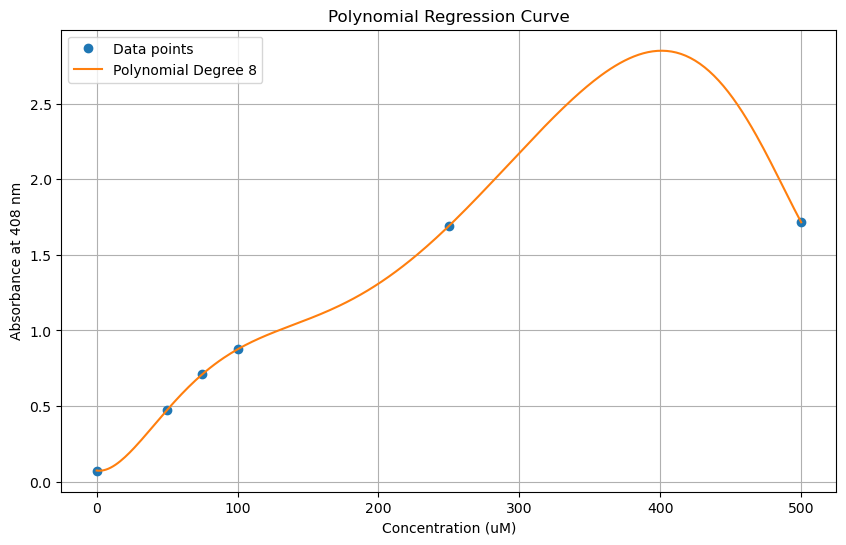

NameError: name 'unknown_absorbances' is not defined

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial

# Sample data setup
x = np.array(standard_data['uM_Concentration'])
y = np.array(standard_data['Absorbance'])

# Fit a polynomial regression model
degree = 8  # Try adjusting this based on your visual inspection
coefs = Polynomial.fit(x, y, deg=degree)

# Function to calculate concentration from a given absorbance
def concentration_from_absorbance(absorbance, coefs):
    # Solving the polynomial equation: coefs(x) - absorbance = 0
    roots = np.roots(coefs.convert().coef - absorbance)
    real_roots = roots[np.isreal(roots)].real
    print(f"Absorbance: {absorbance}, Roots: {real_roots}")  # Diagnostic print
    valid_roots = [root for root in real_roots if 0 <= root <= max(x)]
    return min(valid_roots, default=np.nan)

# Generate x values for plotting the polynomial curve
x_line = np.linspace(min(x), max(x), num=300)
y_line = coefs(x_line)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o', label='Data points')
plt.plot(x_line, y_line, label=f'Polynomial Degree {degree}')
plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance at 408 nm')
plt.title('Polynomial Regression Curve')
plt.legend()
plt.grid(True)
plt.show()

# Assuming unknown_absorbances is defined and contains your unknown sample data
unknown_concentrations = unknown_absorbances.apply(concentration_from_absorbance, args=(coefs,))

# Display calculated concentrations for unknowns
print("Unknowns with Calculated Concentrations:")
print(unknown_concentrations)
